In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()

Dataset is imported from sklearn library

In [3]:
X = diabetes.data
y = diabetes.target

In [4]:
df = pd.DataFrame(X, columns=diabetes.feature_names)
df["target"] = y

data is arranged in data frame

In [5]:
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [6]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


No null values

Distribution of Diabetes Progression

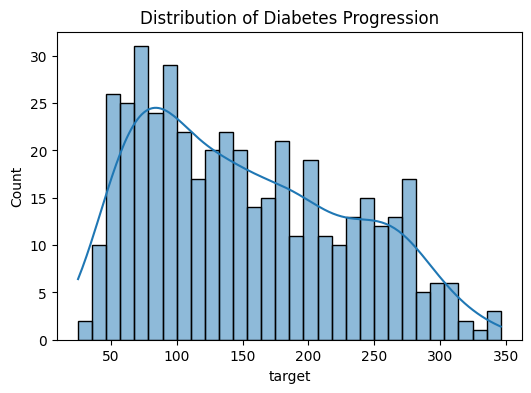

In [7]:
plt.figure(figsize=(6,4))
sns.histplot(df["target"], bins=30, kde=True)
plt.title("Distribution of Diabetes Progression")
plt.show()

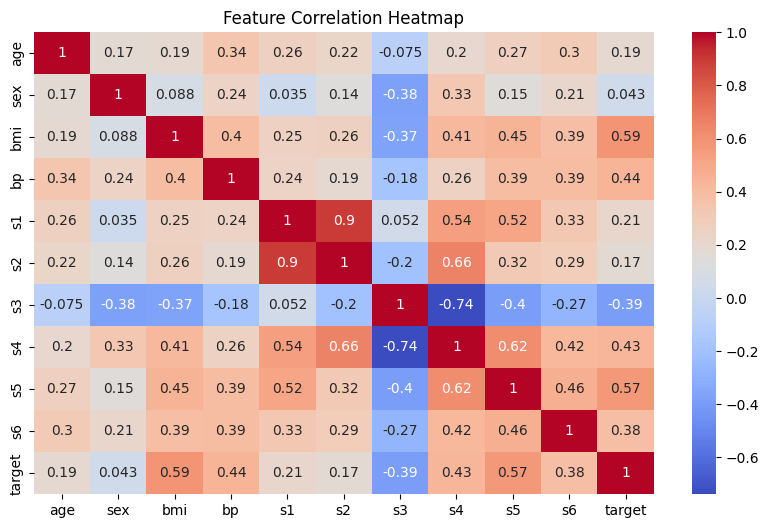

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

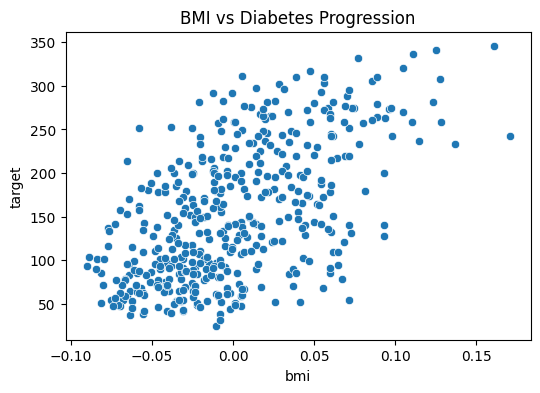

In [9]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["bmi"], y=df["target"])
plt.title("BMI vs Diabetes Progression")
plt.show()

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(32, activation='relu', input_shape=(X_scaled.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(optimizer='adam',loss='mse')

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [14]:
history = model.fit(X_train,y_train,epochs=100,batch_size=16,validation_split=0.2,verbose=1)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 31403.9336 - val_loss: 22296.2949
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 31144.4824 - val_loss: 22091.8379
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 30859.4297 - val_loss: 21844.1523
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 30480.3828 - val_loss: 21539.1074
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 29982.6211 - val_loss: 21139.9023
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 29306.9805 - val_loss: 20637.8418
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 28452.2578 - val_loss: 19997.6152
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 27334.3867 - val_loss: 19204.4102
Epoch 9/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 25991.3945 - val_loss: 18229.9121
Epoch 10/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 24338.3340 - val_loss: 17118.3516
Epoch 11/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2

In [15]:
y_pred = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [16]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 2844.3770515268407
R2 Score: 0.4631378664600875


The Mean Squared Error is: 2866.7958173794864


The R2 Score is: 0.45890643502573447

For inproving the model, more layers are added

In [17]:
model_deep = Sequential([
    Dense(128, activation='relu', input_shape=(X_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model_deep.compile(optimizer='adam', loss='mse')

In [19]:
model_deep.fit(X_train, y_train, epochs=150, batch_size=16, verbose=0)

y_pred_deep = model_deep.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step


In [20]:
print("Deep MSE:", mean_squared_error(y_test, y_pred_deep))
print("Deep R2:", r2_score(y_test, y_pred_deep))

Deep MSE: 2912.4150347257737
Deep R2: 0.4502960328493415


The MSE of second model is: 2912.4150347257737

The R2 of second model is: 0.4502960328493415

The second (improved) model shows a slight performance improvement over the first model. The Mean Squared Error decreased from 2912.41 to 2866.80, indicating that the prediction errors have reduced. Similarly, the R² score increased from 0.4503 to 0.4589, meaning the model now explains a slightly higher proportion of variance in diabetes progression